In [1]:
import os

os.makedirs("docs", exist_ok=True)

article_text = """Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the meaning of a sentence.

Natural Language Processing, or NLP, is the branch of AI that focuses specifically on human
language. NLP powers chatbots, translation tools, and search engines. A key building block of
modern NLP is the embedding, which converts words or sentences into numeric vectors that capture
meaning.

Retrieval-Augmented Generation, or RAG, is a technique that combines a search system with a
language model. Instead of relying only on what a language model memorized during training, RAG
first retrieves relevant, up-to-date information from a document collection, then passes that
information to the model so it can generate a more accurate, grounded answer.

Vector Databases store embeddings and allow fast similarity search across millions of documents.
They are a core infrastructure piece behind modern RAG systems, chatbots, and recommendation
engines used by companies around the world today.
"""

with open("docs/sample_article.txt", "w") as f:
    f.write(article_text)

print("Document created: docs/sample_article.txt")
print("Total characters:", len(article_text))
print("Total words:", len(article_text.split()))

Document created: docs/sample_article.txt
Total characters: 1786
Total words: 262


In [2]:
with open("docs/sample_article.txt", "r") as f:
    loaded_text = f.read()

print("Loaded document preview:\n")
print(loaded_text[:300], "...")

Loaded document preview:

Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from exp ...


In [3]:
!pip install fpdf2

from fpdf import FPDF

pdf = FPDF()
pdf.add_page()
pdf.set_font("Times", size=12)

for line in article_text.split("\n"):
    # Using an explicit width (e.g., 190mm for A4 page with margins) instead of 0
    pdf.multi_cell(190, 8, line)

pdf.output("docs/sample_article.pdf")
print("PDF created: docs/sample_article.pdf")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PDF created: docs/sample_article.pdf


In [4]:
!pip install pypdf

from pypdf import PdfReader

reader = PdfReader("docs/sample_article.pdf")

pdf_text = ""
for page in reader.pages:
    pdf_text += page.extract_text() + "\n"

print("Pages found:", len(reader.pages))
print("\nExtracted PDF text preview:\n")
print(pdf_text[:300], "...")

Pages found: 1

Extracted PDF text preview:

Artificial Intelligence: An Overview
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from expe ...



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
def fixed_size_chunking(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

fixed_chunks = fixed_size_chunking(loaded_text, chunk_size=300, overlap=50)

print("Number of chunks:", len(fixed_chunks))
print("\n--- Chunk 1 ---\n", fixed_chunks[0])
print("\n--- Chunk 2 ---\n", fixed_chunks[1])

Number of chunks: 8

--- Chunk 1 ---
 Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from exp

--- Chunk 2 ---
 ng images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own


In [6]:
!pip install langchain-text-splitters

from langchain_text_splitters import CharacterTextSplitter

char_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=300,
    chunk_overlap=50
)

char_chunks = char_splitter.split_text(loaded_text)

print("Number of chunks:", len(char_chunks))
for i, chunk in enumerate(char_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Created a chunk of size 318, which is longer than the specified 300


Created a chunk of size 359, which is longer than the specified 300


Number of chunks: 7

--- Chunk 1 (36 chars) ---
Artificial Intelligence: An Overview

--- Chunk 2 (270 chars) ---
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 3 (318 chars) ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

--- Chunk 4 (260 chars) ---
Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the 

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(loaded_text)

print("Number of chunks:", len(recursive_chunks))
for i, chunk in enumerate(recursive_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Number of chunks: 9

--- Chunk 1 (36 chars) ---
Artificial Intelligence: An Overview

--- Chunk 2 (270 chars) ---
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 3 (291 chars) ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters

--- Chunk 4 (26 chars) ---
to recommendation systems.

--- Chunk 5 (260 chars) ---
Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in 

In [8]:
import re

def sentence_chunking(text, sentences_per_chunk=2):
    # Simple sentence splitter using punctuation (no extra downloads needed)
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]

    chunks = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = " ".join(sentences[i:i + sentences_per_chunk])
        chunks.append(chunk)
    return chunks

sentence_chunks = sentence_chunking(loaded_text, sentences_per_chunk=2)

print("Number of chunks:", len(sentence_chunks))
for i, chunk in enumerate(sentence_chunks[:4]):
    print(f"\n--- Chunk {i+1} ---")
    print(chunk)

Number of chunks: 7

--- Chunk 1 ---
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 2 ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own.

--- Chunk 3 ---
This approach powers everything from spam filters
to recommendation systems. Deep Learning takes Machine Learning further by using neural networks with many layers.

--- Chunk 4 ---
These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the meaning of a sentence. Natural Language Proces

In [9]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

def token_chunking(text, max_tokens=60, overlap_tokens=10):
    tokens = encoding.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = start + max_tokens
        chunk_tokens = tokens[start:end]
        chunks.append(encoding.decode(chunk_tokens))
        start += max_tokens - overlap_tokens
    return chunks

token_chunks = token_chunking(loaded_text, max_tokens=60, overlap_tokens=10)

print("Number of chunks:", len(token_chunks))
for i, chunk in enumerate(token_chunks[:3]):
    token_count = len(encoding.encode(chunk))
    print(f"\n--- Chunk {i+1} ({token_count} tokens) ---")
    print(chunk)

Number of chunks: 7

--- Chunk 1 (60 tokens) ---
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of

--- Chunk 2 (60 tokens) ---
 learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation

--- Chunk 3 (60 tokens) ---
 This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically disco

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Strategy": [
        "Fixed-size (scratch)",
        "CharacterTextSplitter",
        "RecursiveCharacterTextSplitter",
        "Sentence-based",
        "Token-based"
    ],
    "Number of Chunks": [
        len(fixed_chunks),
        len(char_chunks),
        len(recursive_chunks),
        len(sentence_chunks),
        len(token_chunks)
    ],
    "Avg Chunk Length (chars)": [
        round(sum(len(c) for c in fixed_chunks) / len(fixed_chunks), 1),
        round(sum(len(c) for c in char_chunks) / len(char_chunks), 1),
        round(sum(len(c) for c in recursive_chunks) / len(recursive_chunks), 1),
        round(sum(len(c) for c in sentence_chunks) / len(sentence_chunks), 1),
        round(sum(len(c) for c in token_chunks) / len(token_chunks), 1)
    ]
})

comparison

,Strategy,Number of Chunks,Avg Chunk Length (chars)
0,Fixed-size (scratch),8,265.2
1,CharacterTextSplitter,7,253.3
2,RecursiveCharacterTextSplitter,9,196.8
3,Sentence-based,7,253.4
4,Token-based,7,305.0


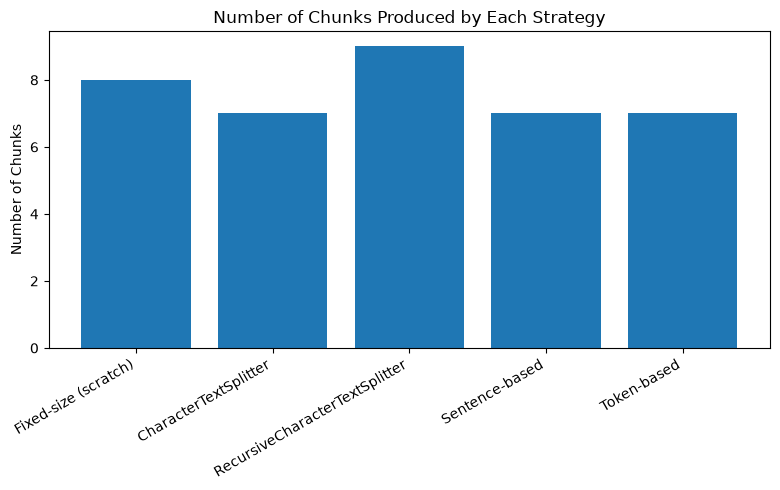

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison["Strategy"], comparison["Number of Chunks"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of Chunks")
plt.title("Number of Chunks Produced by Each Strategy")
plt.tight_layout()
plt.show()